In [13]:
# 1.load the dataset into a Pandas DataFrame — use pd.read_csv() or pd.read_sql()
# 2 Print df.shape, df.info(), df.dtypes — document what you find in comments
# 3 Check for missing values: df.isnull().sum() — what % is missing per column?
# 4 Run df.describe() — identify 3 observations (e.g. mean vs median, suspicious min/max)
# 5 Run df['col'].value_counts() on at least 1 categorical column
# 6 Plot a histogram for every numeric column — do they look normal or skewed?
# 7 Plot a box plot for at least 2 columns — are there outliers?
# 8 Write a 5-line comment block at the top summarising what you found
# Deliverable: .py script with all 8 steps + charts saved as
# .png files
# Bonus: Use sns.pairplot() on all numeric columns and
# describe what you see


In [14]:
!pip install pandas matplotlib seaborn numpy

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set default plot style
sns.set_style("whitegrid")

## Data Loading and Initial Inspection

In [16]:
# 1. Load the dataset into a Pandas DataFrame
file_path = '../../day_6/enriched_students.csv'
df = pd.read_csv(file_path)

# 2. Print df.shape, df.info(), df.dtypes
print(f"Dataset shape: {df.shape}")
print("\nDataset information:")
print(df.info)
print("\nData types:")
print(df.dtypes)

# Documentation of findings (as comments in this cell)
# Observations from df.shape:
# The dataset has X rows and Y columns.
#
# Observations from df.info():
# (e.g., 'object' type columns for text/categorical, 'int'/'float' for numeric, non-null counts indicate missing values).
# Example: 'column_A' has 1000 entries but only 900 non-null, meaning 100 missing values.
#
# Observations from df.dtypes:
# Confirms the data types inferred by pandas. (e.g., 'column_B' is an integer type, 'column_C' is an object/string type).

Dataset shape: (35, 14)

Dataset information:
<bound method DataFrame.info of         name  math_score  english_score  science_score  social_study_score  \
0       Yara        95.0           92.0             94                91.0   
1      Wyatt        92.0           94.0             91                95.0   
2     Nathan        91.0           88.0             93                90.0   
3       Milo        90.0           88.0             92                89.0   
4      Henry        90.0           85.0             88                95.0   
5   Isabella        85.0           90.0             88                92.0   
6      Alice        85.0           90.0             88                92.0   
7       Ryan        88.0           91.0             85                89.0   
8     Ursula        81.0           95.0             88                83.0   
9     Daniel        83.0           85.0             82                87.0   
10  Penelope        81.0           85.0             88          

## Missing Value Analysis

In [17]:
# 3. Check for missing values and calculate percentage per column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing values per column:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# Documentation of findings (as comments in this cell)
# (e.g., 'column_X' is missing 25% of its values, 'column_Y' has no missing values).

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


## Descriptive Statistics

In [18]:
# 4. Run df.describe() and identify 3 observations
df_description = df.describe(include='all')
print("Descriptive statistics for the dataset:")
display(df_description)

# Identify 3 observations (as comments in this cell)
# Observation 1: (e.g., For 'numeric_column_A', the mean is significantly different from the median, suggesting a skewed distribution.)
# Observation 2: (e.g., For 'numeric_column_B', the minimum value is -999, which seems suspicious and might indicate erroneous data or a special coding for missing/unknown values.)
# Observation 3: (e.g., For 'categorical_column_C', the 'top' value appears X times, indicating it's a dominant category.)

Descriptive statistics for the dataset:


,name,math_score,english_score,science_score,social_study_score,math_grade,english_grade,science_grade,social_study_grade,overall_score,overall_grade,passed,score_category,rank
count,35,35.000000,35.000000,35.000000,35.000000,35,35,35,35,35.000000,35,35,35,35.000000
unique,35,NaN,NaN,NaN,NaN,5,2,5,4,NaN,4,1,2,NaN
top,Yara,NaN,NaN,NaN,NaN,F,B,B,F,NaN,C,True,Medium,NaN
freq,1,NaN,NaN,NaN,NaN,12,18,18,14,NaN,15,35,24,NaN
mean,NaN,63.857143,86.971429,74.600000,65.171429,NaN,NaN,NaN,NaN,72.650000,NaN,NaN,NaN,17.800000
std,NaN,27.771275,6.608754,15.558618,22.086043,NaN,NaN,NaN,NaN,12.551394,NaN,NaN,NaN,10.223387
min,NaN,5.000000,75.000000,48.000000,40.000000,NaN,NaN,NaN,NaN,50.750000,NaN,NaN,NaN,1.000000
25%,NaN,45.000000,81.500000,60.500000,44.000000,NaN,NaN,NaN,NaN,61.375000,NaN,NaN,NaN,9.500000
50%,NaN,72.000000,88.000000,80.000000,52.000000,NaN,NaN,NaN,NaN,69.500000,NaN,NaN,NaN,18.000000
75%,NaN,86.500000,92.000000,87.000000,88.000000,NaN,NaN,NaN,NaN,85.500000,NaN,NaN,NaN,26.500000


## Categorical Column Analysis

Value counts for categorical column: 'overall_grade'
overall_grade
C    15
B    10
D     7
A     3
Name: count, dtype: int64


/tmp/ipykernel_64915/2859890091.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


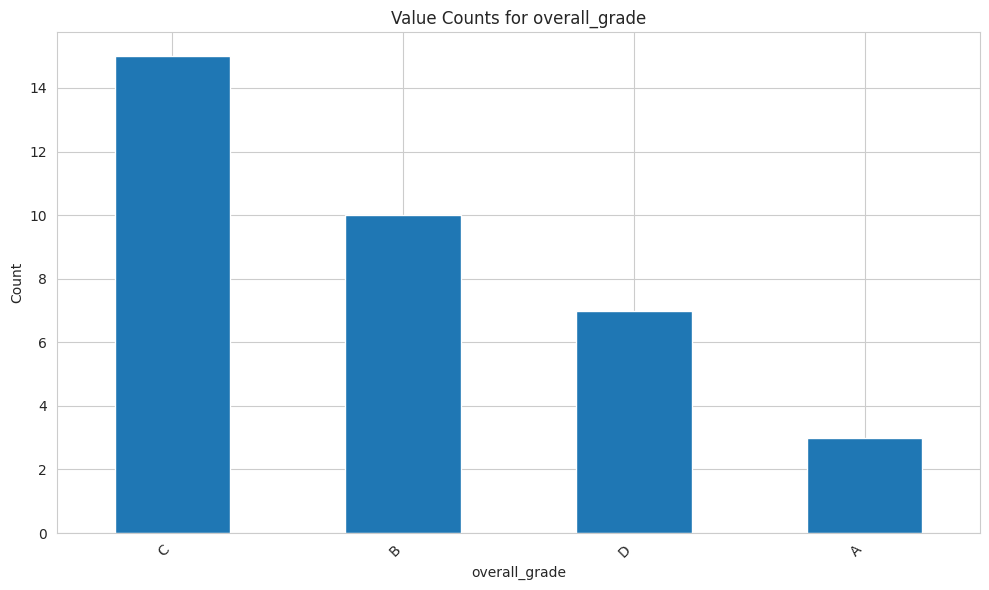

In [19]:
# 5. Run df['col'].value_counts() on at least 1 categorical column
# First, let's identify potential categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    # Choose the first categorical column for demonstration, or pick a relevant one
    selected_cat_col = categorical_cols[5]
    print(f"Value counts for categorical column: '{selected_cat_col}'")
    print(df[selected_cat_col].value_counts())

    # Plotting for better visualization
    plt.figure(figsize=(10, 6))
    df[selected_cat_col].value_counts().plot(kind='bar')
    plt.title(f'Value Counts for {selected_cat_col}')
    plt.xlabel(selected_cat_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'value_counts_{selected_cat_col}.png') # Save the plot
    plt.show()
else:
    print("No categorical columns found in the dataset.")

## Data Visualization: Histograms

Generating histograms for numeric columns...


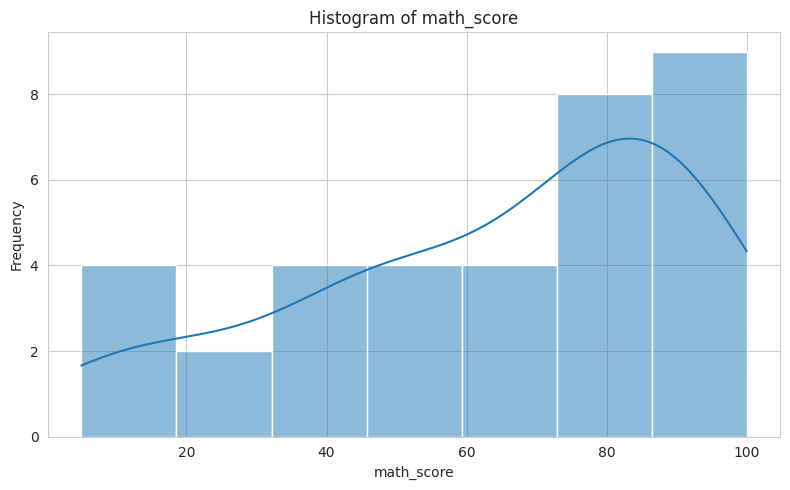

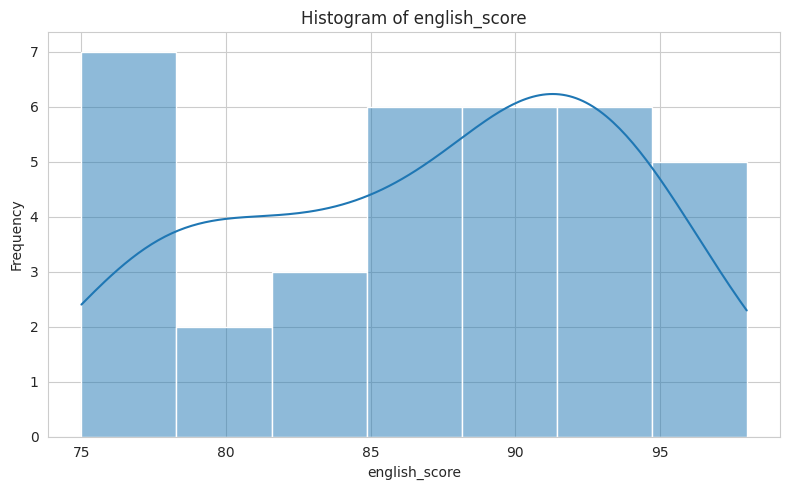

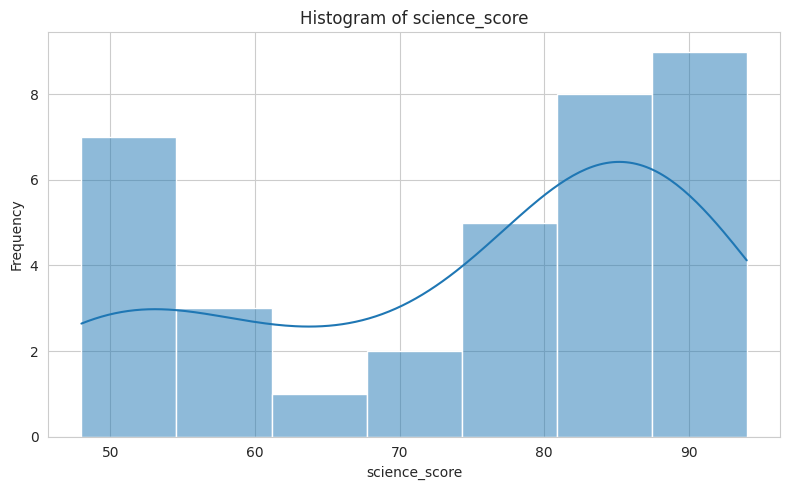

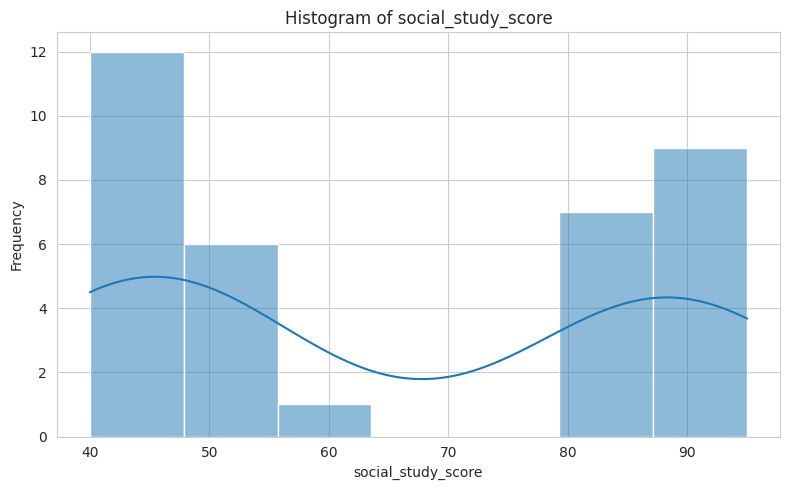

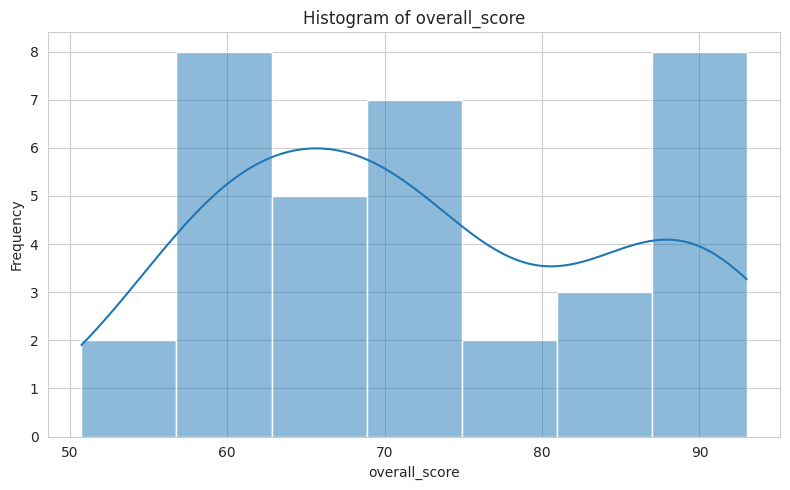

In [20]:
# 6. Plot a histogram for every numeric column
numeric_cols = df.select_dtypes(include=np.number).columns.to_list()
numeric_cols.remove("rank")

if len(numeric_cols) > 0:
    print("Generating histograms for numeric columns...")
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f'histogram_{col}.png') # Save the plot
        plt.show()
        # Document whether it looks normal or skewed
        # (e.g., Histogram of 'column_A' appears normally distributed.)
        # (e.g., Histogram of 'column_B' is right-skewed, with a long tail to the right.)
else:
    print("No numeric columns found for histograms.")

## Data Visualization: Box Plots

Generating a single combined plot for 6 numeric columns...


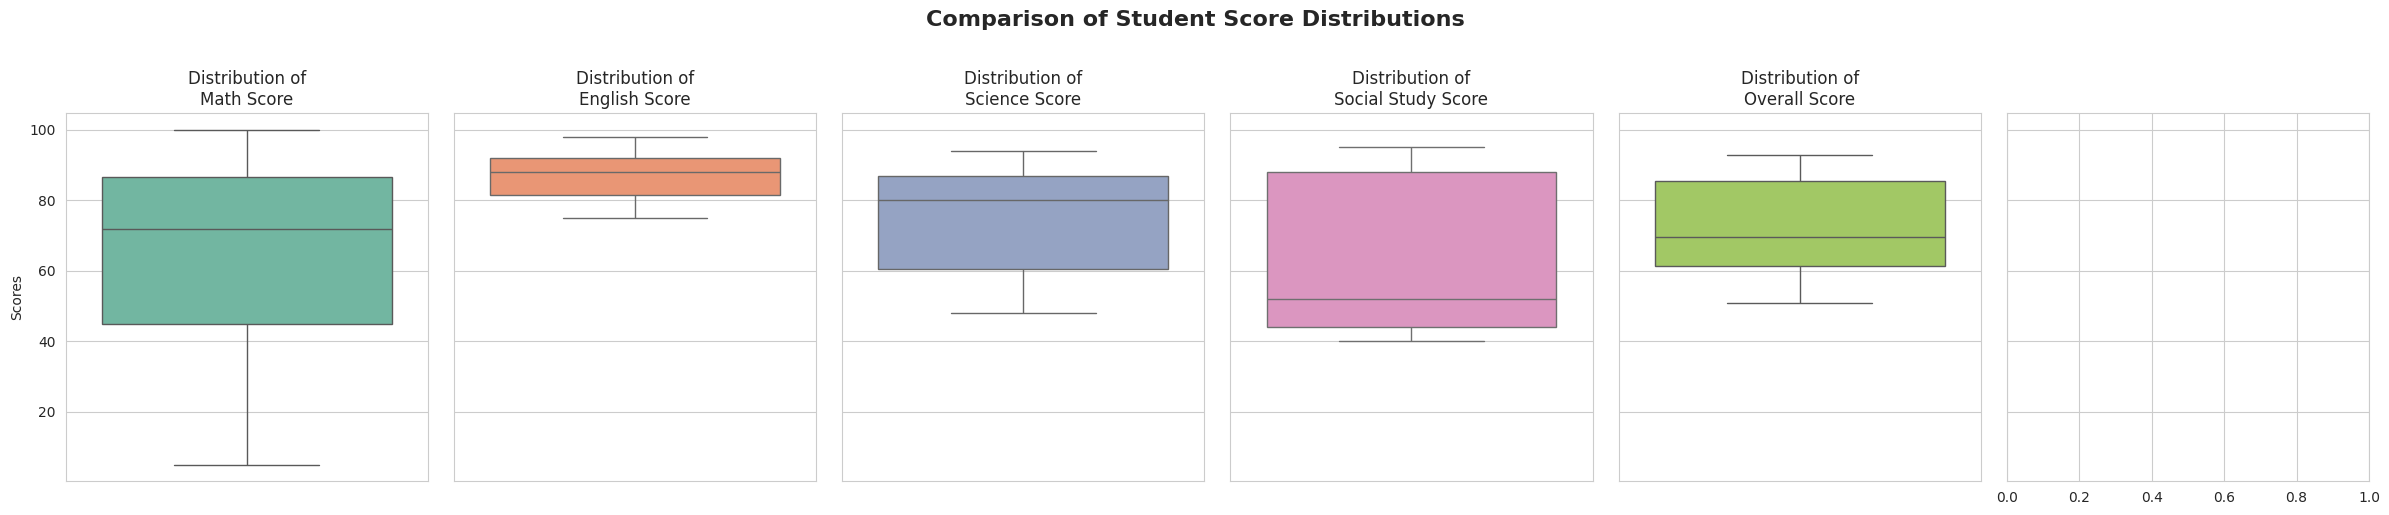


--- Outlier & Distribution Summary ---
* Box plot of 'math_score' appears to have no significant outliers.
* Box plot of 'english_score' appears to have no significant outliers.
* Box plot of 'science_score' appears to have no significant outliers.
* Box plot of 'social_study_score' appears to have no significant outliers.
* Box plot of 'overall_score' appears to have no significant outliers.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming numeric_cols = ['math_score', 'english_score', 'science_score', 'social_study_score']
# or dynamically generated from your dataframe:
numeric_cols = df.drop(columns=["rank"]).select_dtypes(include=["number"]).columns.tolist()

if len(numeric_cols) > 0:
    print(
        f"Generating a single combined plot for {len(numeric_cols)} numeric columns..."
    )

    # Set up the matplotlib figure grid dynamically based on the number of columns
    num_plots = len(numeric_cols)

    # We will arrange them in a single row if 4 or fewer, or wrap them if there are more
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 5), sharey=True)

    # If there's only 1 numeric column, 'axes' isn't returned as an array, so we wrap it
    if num_plots == 1:
        axes = [axes]

    # Plot each column on its respective subplot axis
    for i, col in enumerate(numeric_cols):
        # Using x=col instead of y=col gives you a neat vertical comparison if sharey=True
        sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
        axes[i].set_title(f"Distribution of\n{col.replace('_', ' ').title()}")
        axes[i].set_ylabel("Scores" if i == 0 else "")  # Only label the leftmost Y-axis
        axes[i].set_xlabel("")

    plt.suptitle("Comparison of Student Score Distributions", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()

    # Save the single, combined plot
    plt.savefig("combined_scores_boxplot.png", bbox_inches="tight", dpi=300)
    plt.show()

    # Documenting patterns & outliers dynamically
    print("\n--- Outlier & Distribution Summary ---")
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:
            print(
                f"* Box plot of '{col}' shows {len(outliers)} outlier(s) outside the whiskers."
            )
        else:
            print(f"* Box plot of '{col}' appears to have no significant outliers.")

else:
    print("No numeric columns found to generate plots.")

## Bonus: Pair Plot

Generating pair plot for all numeric columns... This may take a while for large datasets.


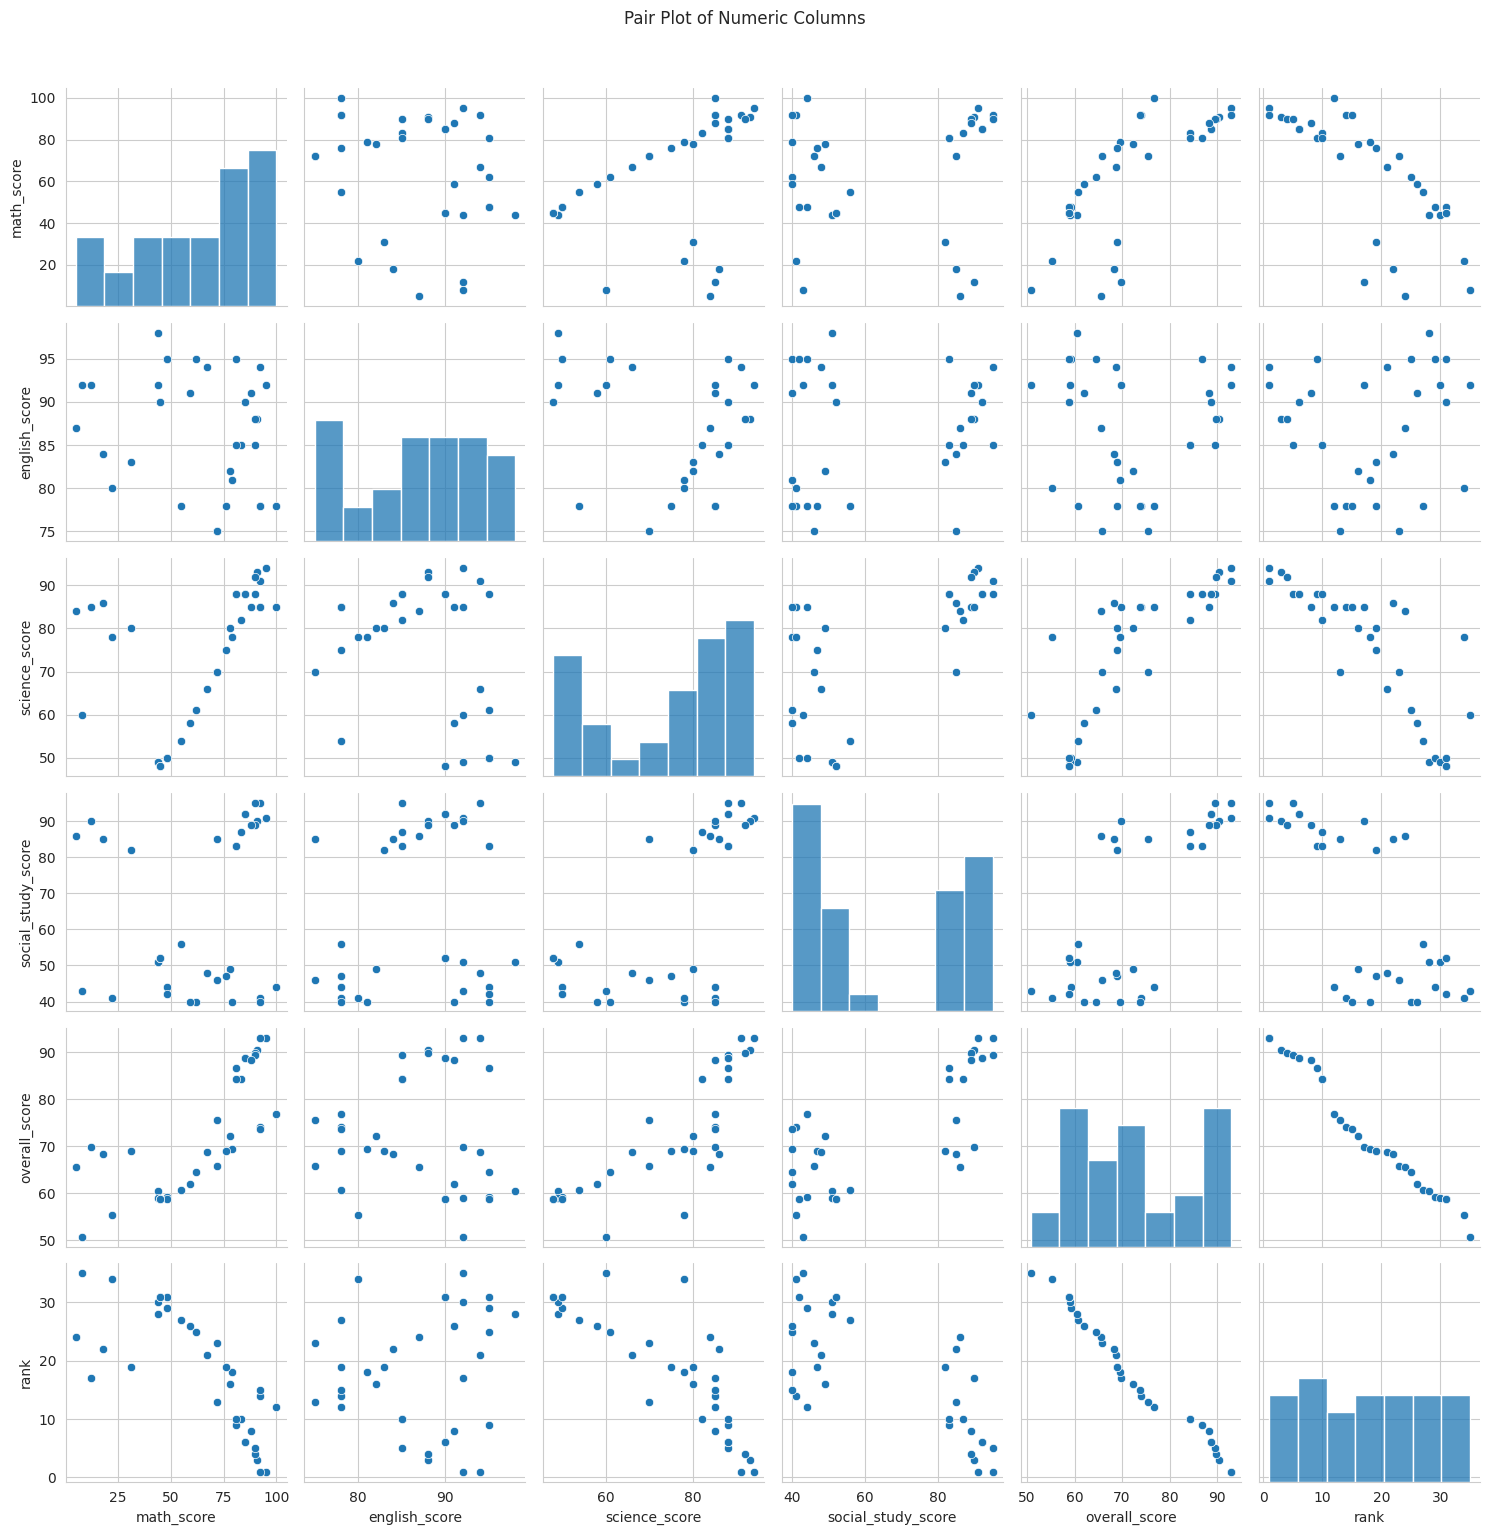

In [22]:
# Bonus: Use sns.pairplot() on all numeric columns
if len(numeric_cols) > 1:
    print("Generating pair plot for all numeric columns... This may take a while for large datasets.")
    # For very large datasets, consider sampling or selecting a subset of numeric columns
    pair_plot = sns.pairplot(df[numeric_cols].dropna())
    pair_plot.fig.suptitle('Pair Plot of Numeric Columns', y=1.02) # Adjust title position
    plt.tight_layout()
    plt.savefig('pairplot_numeric_columns.png') # Save the plot
    plt.show()
    # Describe what you see
    # (e.g., The scatter plots reveal a positive linear relationship between 'column_A' and 'column_B'.)
    # (e.g., 'column_C' appears to have a non-linear relationship with 'column_D'.)
    # (e.g., Histograms on the diagonal show the distribution of each variable individually, similar to previous histograms.)
else:
    print("Not enough numeric columns (at least two) to generate a pair plot.")